# Density estimator (by moments)

This notebook runs the end-to-end pipeline implemented in `density_estimator_pipeline.py`:

1. **Moments** — empirical moments from samples (or fixed true moments).
2. **Bandwidth `a`** — grid search minimizing the asymptotic MISE proxy `mise_estimator`.
3. **Hermite coefficients** — map moments to coefficients via `hermite_coefficient`.
4. **Post-process** — `negative_density_post_process` adds OSQP constraints so the estimator is nonnegative on a grid.
5. **Plots** — `display` / `run_hermite_estimation_pipeline` compare true PDF, raw estimator, and QP-corrected density.

Optional: **moment completion** (`iterative_moment_completion`).

In [4]:
# Dependencies: numpy, scipy, matplotlib, seaborn, cvxpy, osqp
import numpy as np
from scipy.stats import johnsonsu, norm  # johnsonsu: uncomment skewed example below

from density_estimator_pipeline import (
    BimodalNormal,
    iterative_moment_completion,
    list_moment,
    plot_completed_vs_original,
    plot_energy_sum_comparison,
    run_hermite_estimation_pipeline,
)


## Example: standard normal

Adjust `m`, `M`, `a_grid`, and `dist` for other targets (e.g. `scipy.stats.t`, `johnsonsu(...)`, `BimodalNormal()`).

Starting pipeline for norm distribution...
Generating 100000 samples and empirical moments for norm...


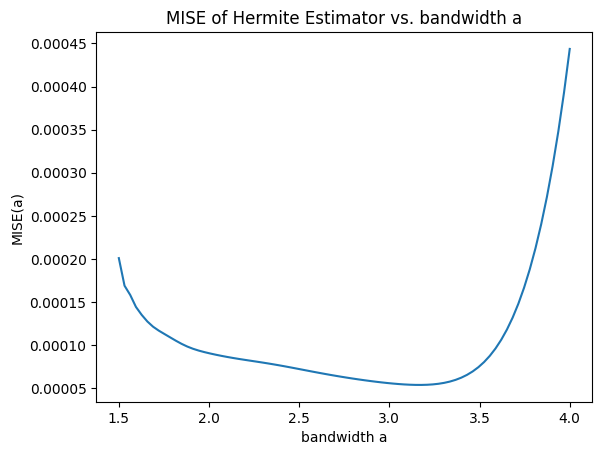

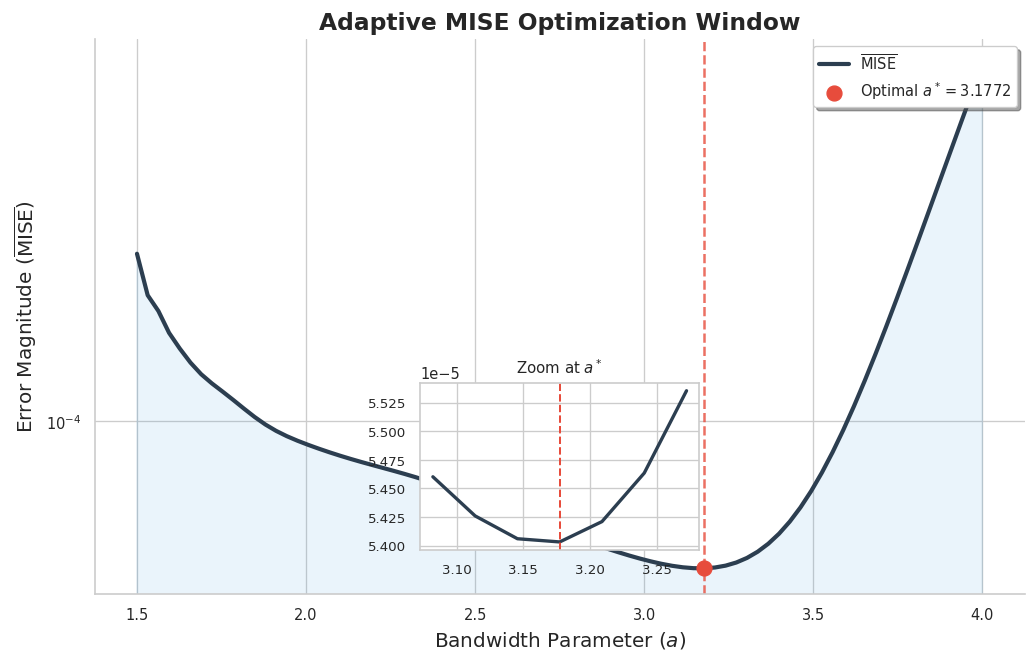

5.4031559132684696e-05
Optimal scale 'a' found: 3.1772
Round: 1
Round 1 successful. Constraints: 5
Round: 2
Round 2 successful. Constraints: 10
Round: 3
Round 3 successful. Constraints: 14
Round: 4
Round 4 successful. Constraints: 17
Round: 5
Round 5 successful. Constraints: 18
Round: 6
Global minimum: 2.2676585915148098e-09 (Success)


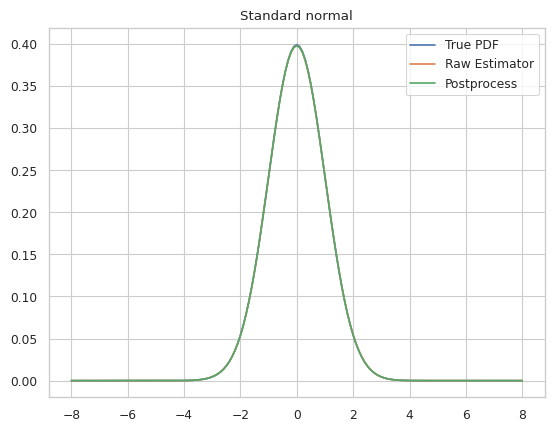

/content/drive/MyDrive/density_estimator_pipeline.py:605: RuntimeWarning: invalid value encountered in log
  plt.plot(x, np.log(est), label='Raw Estimator')
/content/drive/MyDrive/density_estimator_pipeline.py:606: RuntimeWarning: invalid value encountered in log
  plt.plot(x, np.log(post), label='Postprocess')


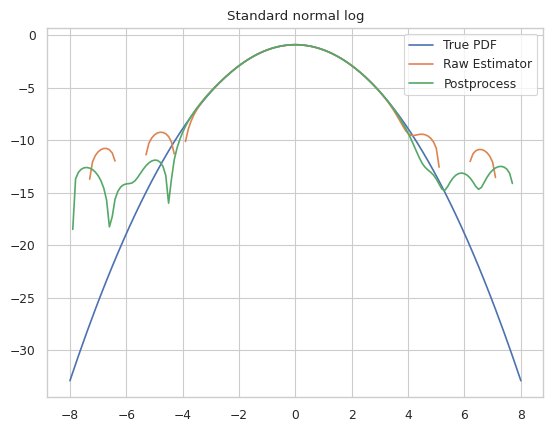

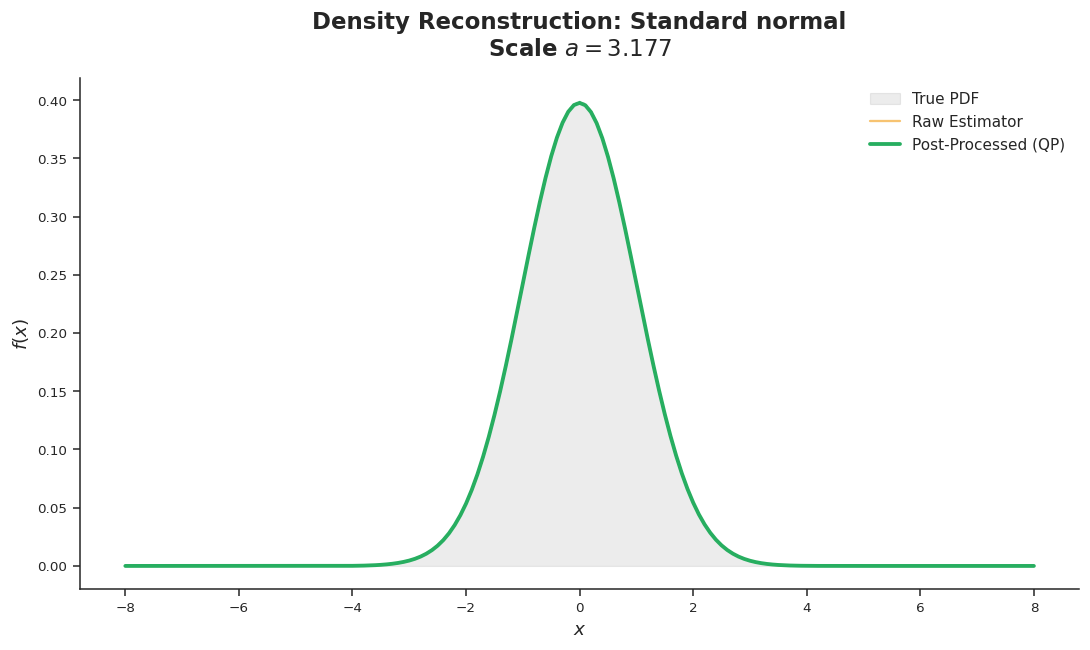

np.float64(3.1772151898734178)

In [5]:
np.random.seed(42)

dist = norm(loc=0, scale=1)

a_grid = np.linspace(1.5, 4.0, 80)
x_range = np.linspace(-8, 8, 161)

best_a, weights = run_hermite_estimation_pipeline(
    dist,
    n=100000,
    m=50,
    M=100,
    a_grid=a_grid,
    x_range=x_range,
    dist_name="Standard normal",
    richardson=False,
)
best_a

## Example: Johnson SU (skewed)

Starting pipeline for johnsonsu distribution...
Generating 100000 samples and empirical moments for johnsonsu...


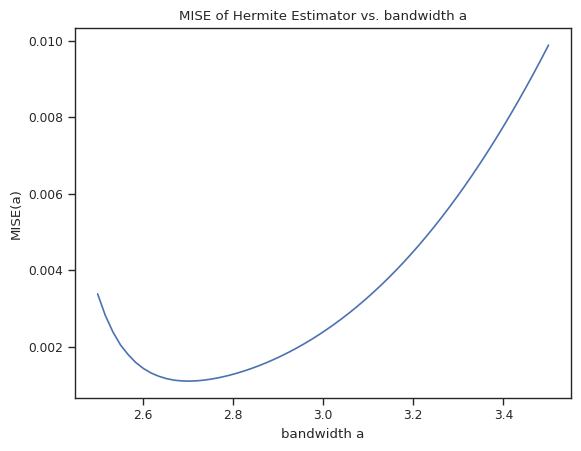

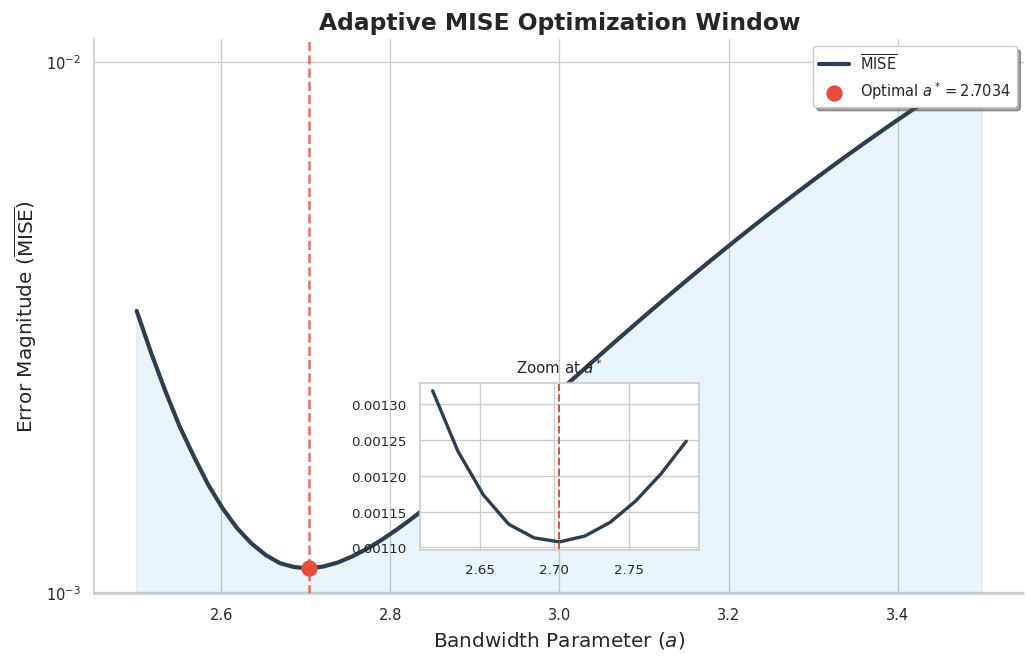

0.0011076599425804776
Optimal scale 'a' found: 2.7034
Round: 1
Round 1 successful. Constraints: 3
Round: 2
Round 2 successful. Constraints: 6
Round: 3
Round 3 successful. Constraints: 10
Round: 4
Round 4 successful. Constraints: 13
Round: 5
Round 5 successful. Constraints: 16
Round: 6
Termination threshold reached (-5.45e-08 > -1e-07).


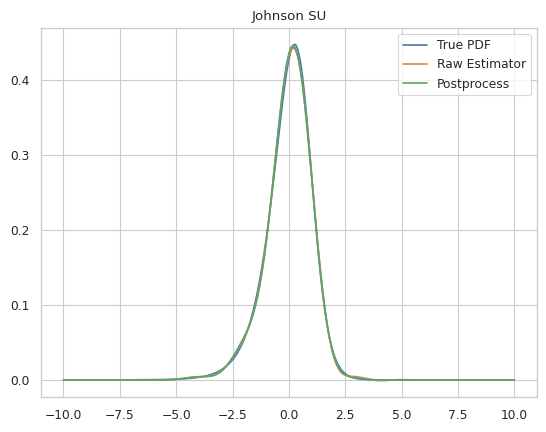

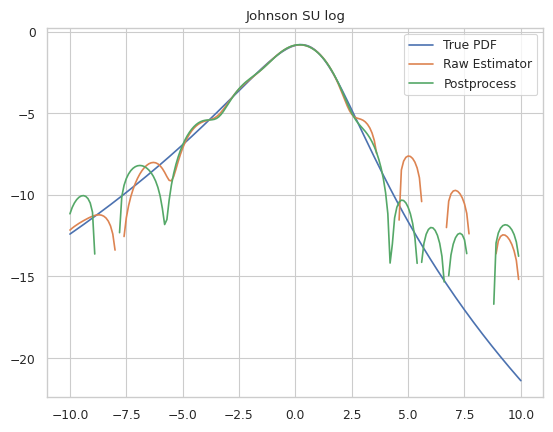

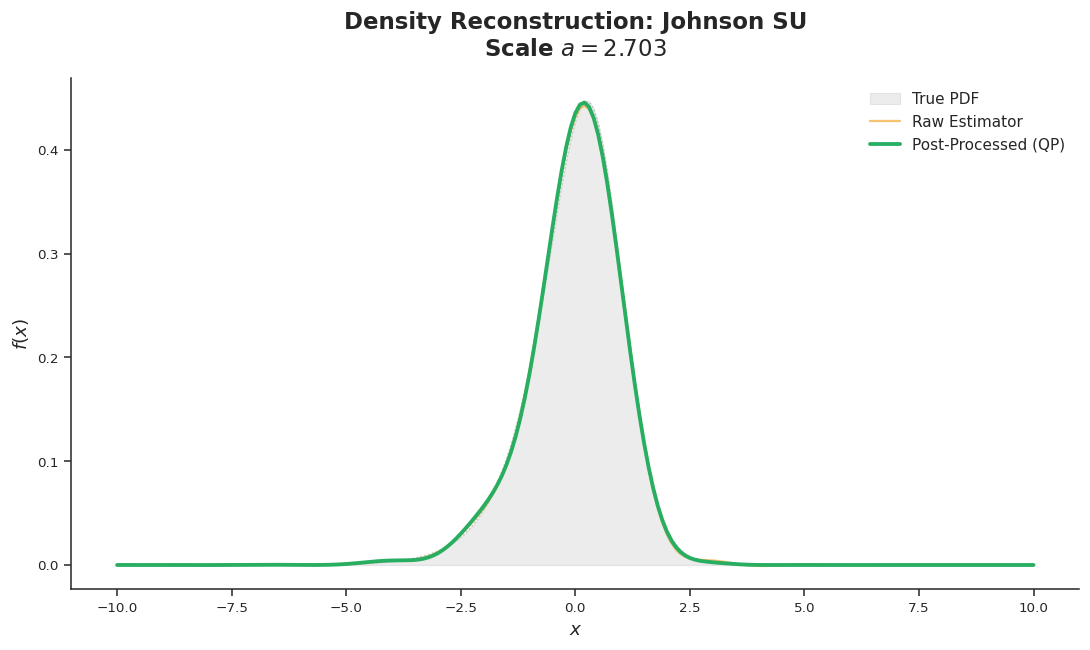

In [12]:
np.random.seed(180)
dist = johnsonsu(1.08, 2.18, loc=1.0, scale=1.76)
a_grid = np.linspace(2.5, 3.5, 60)
best_a, weights = run_hermite_estimation_pipeline(
    dist, n=100000, m=35, M=70, a_grid=a_grid,
    x_range=np.linspace(-10, 10, 201), dist_name="Johnson SU", richardson=False,
)

## Optional: moment completion

Extend a partial moment vector.

Starting pipeline for norm distribution...
Using provided moments for norm pipeline...


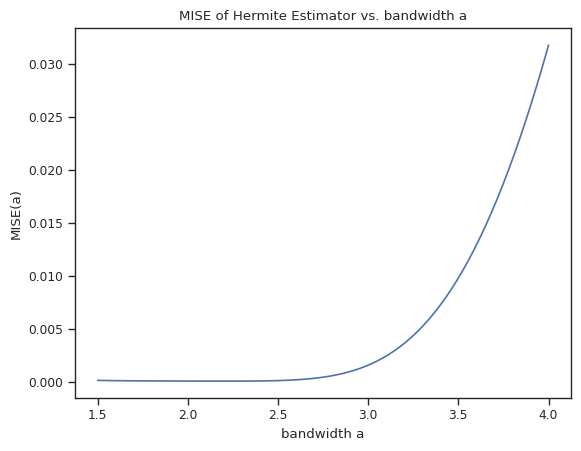

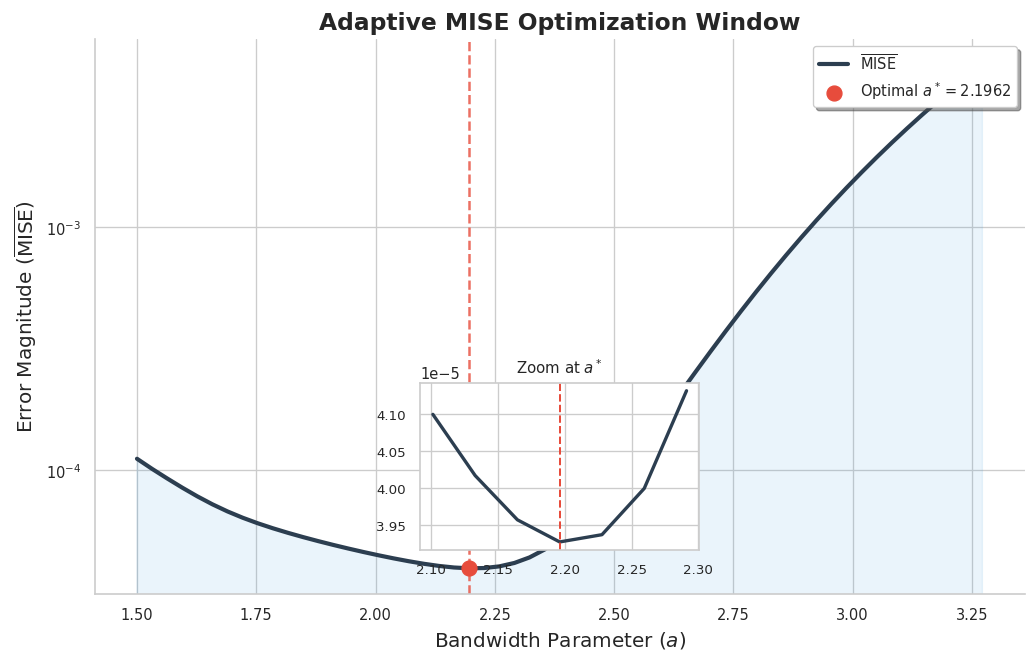

3.927769254370879e-05
Optimal scale 'a' found: 2.1962
Round: 1
Round 1 successful. Constraints: 5
Round: 2
Round 2 successful. Constraints: 9
Round: 3
Round 3 successful. Constraints: 15
Round: 4
Round 4 successful. Constraints: 19
Round: 5
Termination threshold reached (-6.86e-08 > -1e-07).


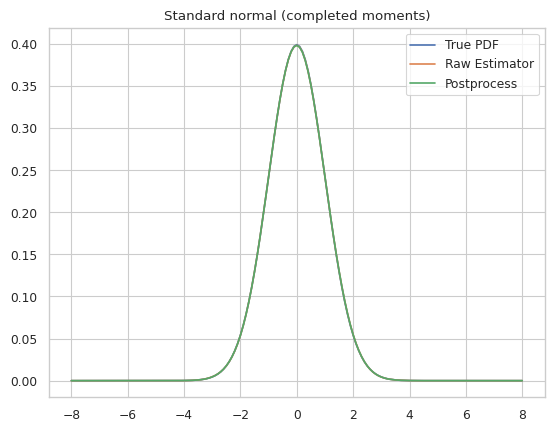

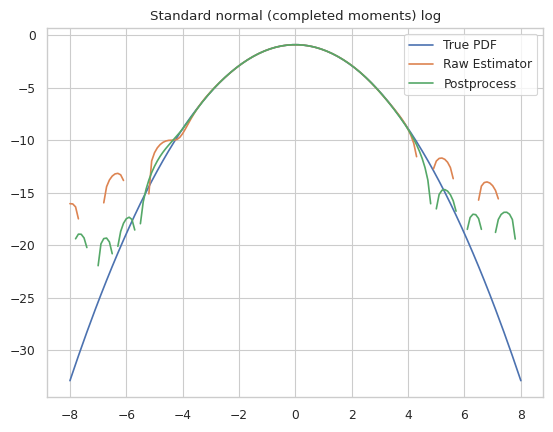

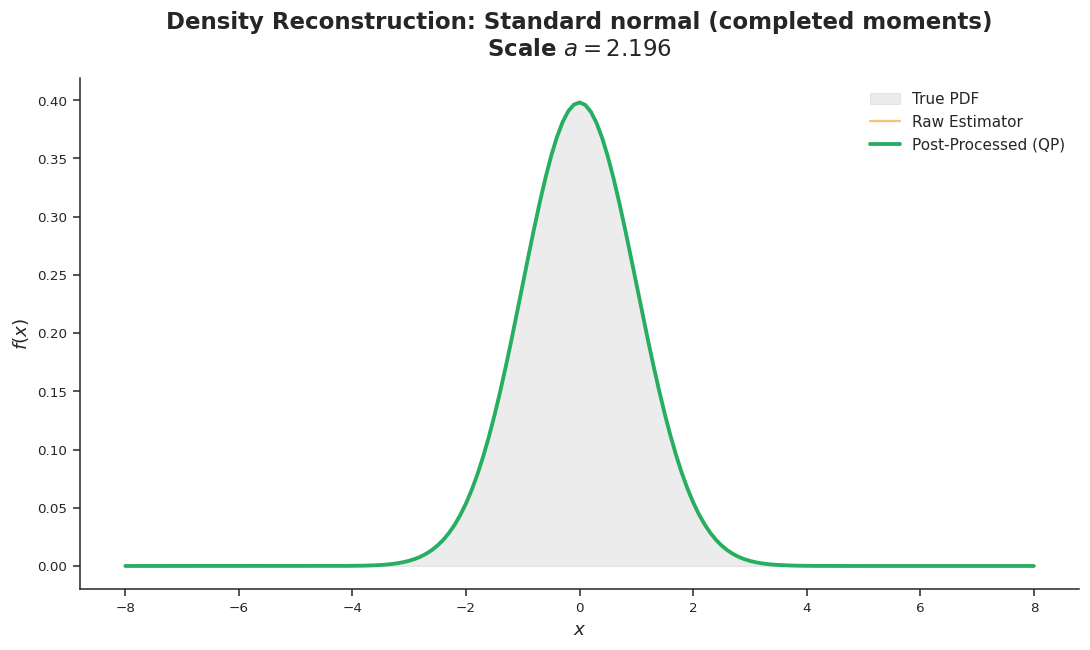

np.float64(2.1962025316455698)

In [15]:
# Match the example above (same seed / sample size) so moments[:41] aligns with that experiment
np.random.seed(42)
dist_mc = norm(loc=0, scale=1)
n_samp = 100_000
M_full = 100
data = dist_mc.rvs(n_samp)
powers = np.arange(M_full + 1)
moments = np.mean(data[:, None] ** powers, axis=0)

completed_moments, _ = iterative_moment_completion(moments[:41], target_order=61)

# Same pipeline as the main example; pass known=41 so MISE uses the original partial count
a_grid = np.linspace(1.5, 4.0, 80)
x_range = np.linspace(-8, 8, 161)
best_a_completed, weights_completed = run_hermite_estimation_pipeline(
    dist_mc,
    n=n_samp,
    m=40,
    M=61,
    a_grid=a_grid,
    x_range=x_range,
    moments=completed_moments,
    dist_name="Standard normal (completed moments)",
    richardson=False,
    known=41,
)
best_a_completed